In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# surpress futre warnings
import warnings
import json
from utils import * 
warnings.simplefilter(action='ignore', category=FutureWarning)
import sys
import os
from pathlib import Path
# Add the src directory to the Python path
sys.path.append(os.path.abspath("../src"))
from guess_llm.probe.test import load_config

from scipy.stats import spearmanr
import seaborn as sns
import scienceplots

sns.set_style('whitegrid')
plt.style.use('science')
plt.rcParams['font.family'] = 'sans-serif'

saves_folder = os.path.join(Path(os.getcwd()).parent, 'saves/guess_llm')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
model_name = 'Llama-2-7b-hf'
save_names = {
    '1.0': f'', # path to the saved model for magnitude 1.0
    '10.0': f'', # path to the saved model for magnitude 10.0
    '1000.0': f'', # path to the saved model for magnitude 1000.0
    '10000.0': f'', # path to the saved model for magnitude 10000.0
}

results_df = pd.DataFrame()

for train_type, save_path in save_names.items():
    # Load the data
    test_df = pd.read_csv(os.path.join(saves_folder, save_path, 'test_results.csv'))
    test_df['eval_type'] = 'test'
    test_df['train_type'] = train_type
    results_df = pd.concat([results_df, test_df], ignore_index=True)

results_df['y'] = results_df['y'].apply(lambda x: json.loads(x))
results_df['pred_quantiles'] = results_df['pred_quantiles'].apply(lambda x: json.loads(x))
results_df['pred_exp_quantiles'] = results_df['pred_exp_quantiles'].apply(lambda x: json.loads(x))
results_df['train'] = results_df['train'].apply(lambda x: json.loads(x))
results_df['y_test'] = results_df['y_test'].apply(lambda x: json.loads(x))

config = load_config(os.path.join(saves_folder, save_names['1.0']))
QUANTILE_LIST = config.model.quantiles
EPSILON = 1e-3

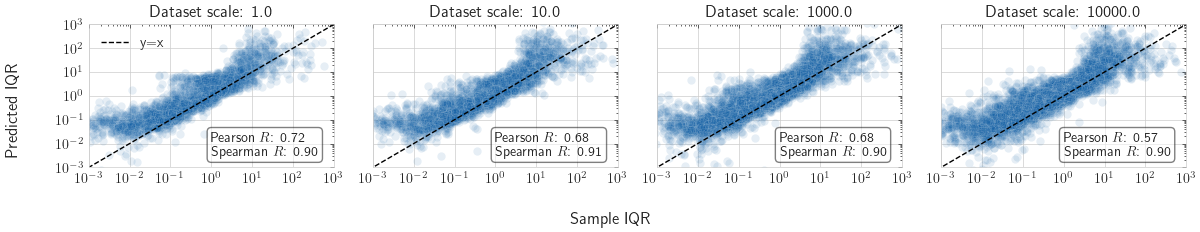

In [8]:
from scipy.stats import pearsonr


# True IQR vs prediced IQR
epsilon = 0.01

def plot_iqr_scatter(ax, df, normalised=True):
    df = df.copy()
    if normalised:
        df['pred_iqr'] = df['pred_exp_quantiles'].apply(lambda x: get_normalised_iqr_from_quantiles(x, QUANTILE_LIST))
        df['sample_iqr'] = df['y'].apply(lambda x: get_normalised_iqr(x))
    else:
        df['pred_iqr'] = df['pred_exp_quantiles'].apply(lambda x: x[QUANTILE_LIST.index(0.75)] - x[QUANTILE_LIST.index(0.25)])
        df['sample_iqr'] = df['y'].apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
    this_df = df[df['pred_iqr'] > 0]
    pr, p = pearsonr(np.log10(this_df['sample_iqr'] + 10), np.log10(this_df['pred_iqr'] + 10))
    #pr, p = pearsonr(np.log10(df['sample_iqr'] + 10), np.log10(df['pred_iqr'] + 10))
    sr, p = spearmanr(df['sample_iqr'], df['pred_iqr'])
    sns.scatterplot(data=df, x='sample_iqr', y='pred_iqr', ax=ax, alpha=0.1)
    ax.text(
        0.5, 0.25, 
        f'Pearson $R$: {pr:.2f} \n Spearman $R$: {sr:.2f}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='black')
    )
    ax.set_xscale('log')
    ax.set_yscale('log')

fig, ax = plt.subplots(1, 4, figsize=(12, 2.4), sharex=True, sharey=True)

for i, scale in enumerate(['1.0', '10.0', '1000.0', '10000.0']):
    plot_iqr_scatter(ax[i], results_df[results_df.train_type==scale], normalised=True)
    x = y = np.arange(0, 1000, 1)
    ax[i].plot(x, y, color='black', linestyle='--', label='y=x')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_title(f'Dataset scale: {scale}')
    ax[i].set_xlim([1e-3, 1000])
    ax[i].set_ylim([1e-3, 1000])
ax[0].legend(loc='upper left')
fig.supylabel('Predicted IQR', x=-0.005)
fig.supxlabel('Sample IQR')
plt.tight_layout()
plt.show()

In [11]:
# Coverage Intervals 
results_df['95_coverage'] = results_df.apply(lambda x: get_coverage_intervals(x['y'], x['pred_exp_quantiles'], config.model.quantiles, ci=95), axis=1)
results_df['90_coverage'] = results_df.apply(lambda x: get_coverage_intervals(x['y'], x['pred_exp_quantiles'], config.model.quantiles, ci=90), axis=1)
results_df['50_coverage'] = results_df.apply(lambda x: get_coverage_intervals(x['y'], x['pred_exp_quantiles'], config.model.quantiles, ci=50), axis=1)

print_df = results_df[results_df.train_type.isin(['1.0', '10.0', '1000.0', '10000.0'])].groupby('train_type')[['95_coverage', '90_coverage', '50_coverage']].aggregate(['mean', 'sem']).unstack().reset_index()
print_df.columns = ['ci', 'key', 'train_type', 'val']
print_df = print_df.pivot(index=['train_type', 'ci'], columns='key', values='val')
print_df['print_val'] = print_df.apply(lambda x: f"{x['mean'] * 100:.1f} ± {x['sem'] * 100:.1f}", axis=1)
print_df = print_df[['print_val']].reset_index().pivot(index='train_type', columns='ci', values='print_val')
display(print_df)
print(print_df.to_latex())

ci,50_coverage,90_coverage,95_coverage
train_type,,,
1.0,53.0 ± 0.4,90.9 ± 0.3,95.5 ± 0.2
10.0,52.7 ± 0.5,91.3 ± 0.3,96.1 ± 0.2
1000.0,51.4 ± 0.3,90.7 ± 0.3,95.7 ± 0.2
10000.0,48.2 ± 0.3,90.5 ± 0.2,95.4 ± 0.2


\begin{tabular}{llll}
\toprule
ci & 50_coverage & 90_coverage & 95_coverage \\
train_type &  &  &  \\
\midrule
1.0 & 53.0 ± 0.4 & 90.9 ± 0.3 & 95.5 ± 0.2 \\
10.0 & 52.7 ± 0.5 & 91.3 ± 0.3 & 96.1 ± 0.2 \\
1000.0 & 51.4 ± 0.3 & 90.7 ± 0.3 & 95.7 ± 0.2 \\
10000.0 & 48.2 ± 0.3 & 90.5 ± 0.2 & 95.4 ± 0.2 \\
\bottomrule
\end{tabular}

